In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import src.data
from src.data import load_daily, load_interval, clean, PORTFOLIOS
from src.features import add_calendar_features

REPO_ROOT = Path("..")
src.data.EXCEL_PATH = str(REPO_ROOT / "data" / "raw" / "datathon-data.xlsx")
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
SLIDES_DIR = REPO_ROOT / "output" / "slides"
SLIDES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Excel: {src.data.EXCEL_PATH} (exists: {os.path.exists(src.data.EXCEL_PATH)})")
print(f"Slides out: {SLIDES_DIR}")

Excel: ../data/raw/datathon-data.xlsx (exists: True)
Slides out: ../output/slides


In [2]:
daily = {}
interval = {}

for p in PORTFOLIOS:
    daily_path = PROCESSED_DIR / f"daily_{p}.csv"
    interval_path = PROCESSED_DIR / f"interval_{p}.csv"

    if daily_path.exists():
        daily[p] = pd.read_csv(daily_path, parse_dates=["Date"])
        interval[p] = pd.read_csv(interval_path, parse_dates=["Date"])
    else:
        daily[p] = add_calendar_features(clean(load_daily(p)))
        interval[p] = clean(load_interval(p))

    print(f"{p}: {len(daily[p])} daily rows, {len(interval[p])} interval rows")

A: 701 daily rows, 3911 interval rows
B: 706 daily rows, 4158 interval rows
C: 721 daily rows, 4313 interval rows
D: 731 daily rows, 4067 interval rows


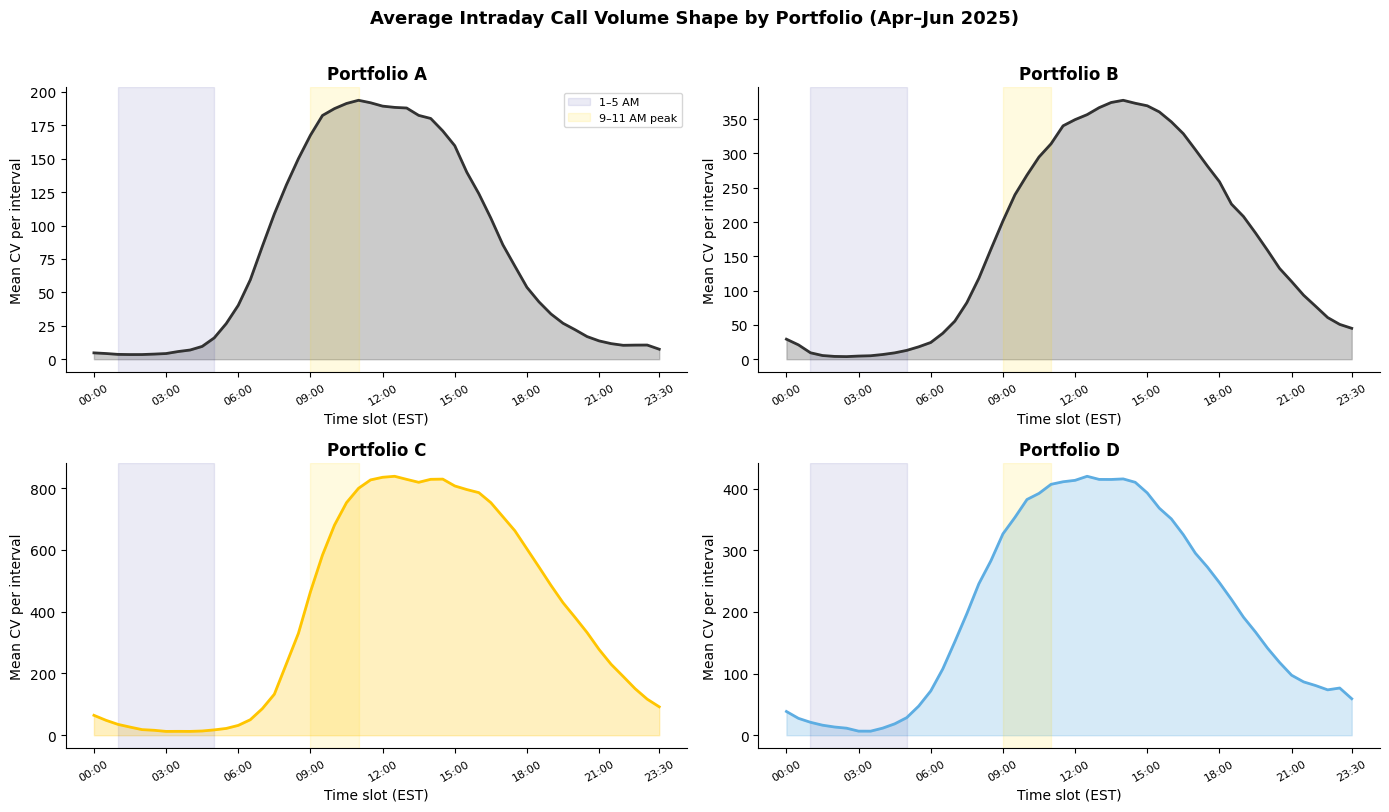

Saved slide3_intraday_shape.png


In [ ]:
intraday_cv = {}
for p in PORTFOLIOS:
    df = interval[p].copy()
    df["SlotIndex"] = df.groupby("Date").cumcount()
    intraday_cv[p] = df.groupby("SlotIndex")["CV"].mean()

slot_labels = [f"{h:02d}:{m}" for h in range(24) for m in ("00", "30")]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()
COLORS = ["#323232", "#323232", "#FFC500", "#5DADE2"]

for i, p in enumerate(PORTFOLIOS):
    ax = axes[i]
    vals = intraday_cv[p].reindex(range(48), fill_value=0)
    ax.fill_between(range(48), vals, alpha=0.25, color=COLORS[i])
    ax.plot(range(48), vals, color=COLORS[i], linewidth=2)

    ax.axvspan(2, 10, alpha=0.08, color="navy", label="1–5 AM")
    ax.axvspan(18, 22, alpha=0.12, color="gold", label="9–11 AM peak")

    ax.set_title(f"Portfolio {p}", fontweight="bold")
    ax.set_xlabel("Time slot (EST)")
    ax.set_ylabel("Mean CV per interval")
    ax.set_xticks([0, 6, 12, 18, 24, 30, 36, 42, 47])
    ax.set_xticklabels([slot_labels[s] for s in [0, 6, 12, 18, 24, 30, 36, 42, 47]], rotation=30, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Average Intraday Call Volume Shape by Portfolio (Apr–Jun 2025)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide3_intraday_shape.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved slide3_intraday_shape.png to ")

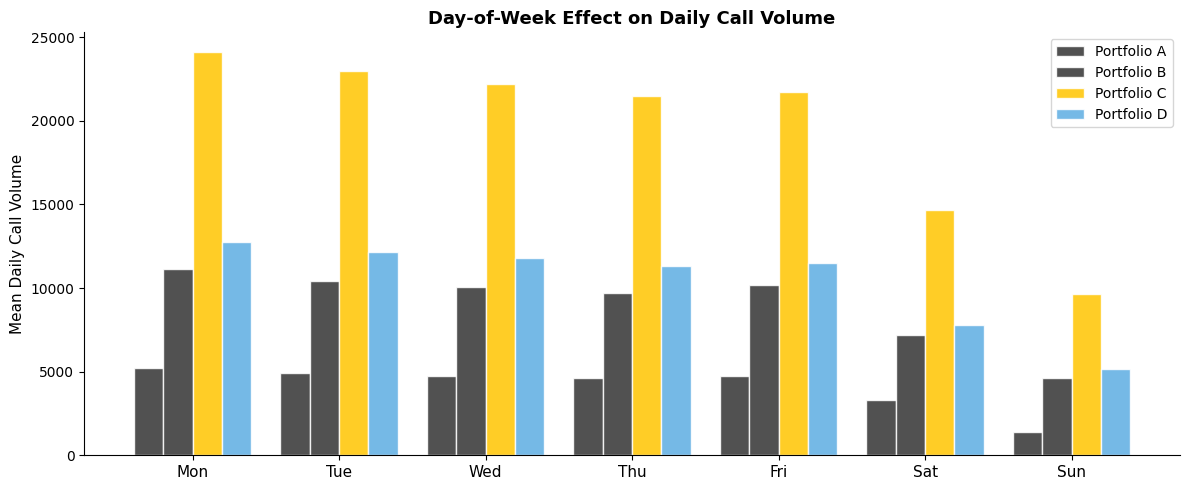

Saved slide3_dow_effect.png


In [ ]:
DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

dow_cv = {}
for p in PORTFOLIOS:
    df = daily[p].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df = df[~((df["Date"].dt.year == 2025) & (df["Date"].dt.month == 8))]
    dow_cv[p] = df.groupby("DayOfWeek")["CV"].mean()

x = np.arange(7)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, p in enumerate(PORTFOLIOS):
    vals = [dow_cv[p].get(d, 0) for d in range(7)]
    bars = ax.bar(x + i * width, vals, width, label=f"Portfolio {p}", color=COLORS[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(DOW_NAMES, fontsize=11)
ax.set_ylabel("Mean Daily Call Volume", fontsize=11)
ax.set_title("Day-of-Week Effect on Daily Call Volume", fontsize=13, fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide3_dow_effect.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved slide3_dow_effect.png to ")

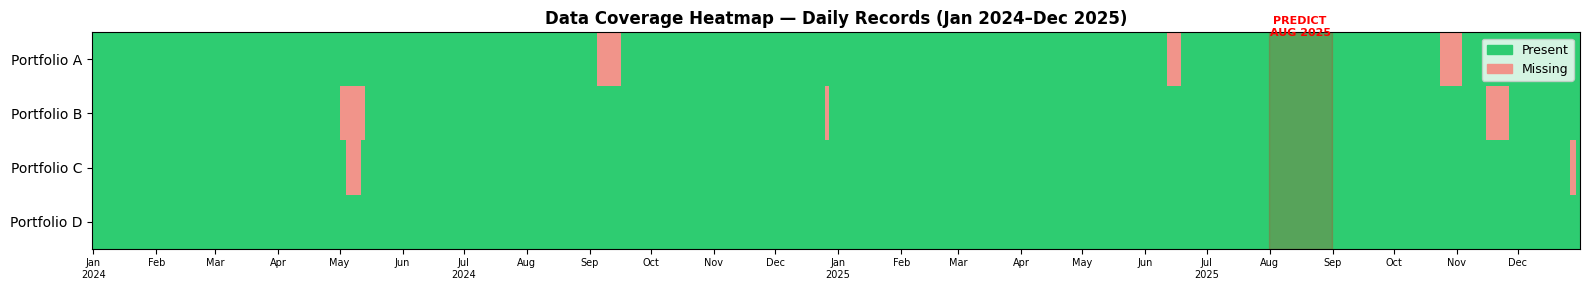

Saved slide3_missing_heatmap.png


In [ ]:
import matplotlib.colors as mcolors

full_range = pd.date_range("2024-01-01", "2025-12-31", freq="D")
presence = np.zeros((4, len(full_range)), dtype=float)

for i, p in enumerate(PORTFOLIOS):
    present = set(pd.to_datetime(daily[p]["Date"]).dt.normalize())
    for j, d in enumerate(full_range):
        if d.normalize() in present:
            presence[i, j] = 1.0
        else:
            presence[i, j] = 0.0

fig, ax = plt.subplots(figsize=(16, 3))
cmap = mcolors.ListedColormap(["#F1948A", "#2ECC71"])
ax.imshow(presence, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")

aug_start = (pd.Timestamp("2025-08-01") - full_range[0]).days
aug_end = (pd.Timestamp("2025-08-31") - full_range[0]).days
ax.axvspan(aug_start - 0.5, aug_end + 0.5, color="red", alpha=0.2, zorder=2)
ax.text((aug_start + aug_end) / 2, -0.8, "PREDICT\nAUG 2025",
        ha="center", va="top", fontsize=8, fontweight="bold", color="red")

month_ticks, month_labels = [], []
for year in [2024, 2025]:
    for month in range(1, 13):
        dt = pd.Timestamp(f"{year}-{month:02d}-01")
        if full_range[0] <= dt <= full_range[-1]:
            month_ticks.append((dt - full_range[0]).days)
            month_labels.append(dt.strftime("%b\n%Y") if month in [1, 7] else dt.strftime("%b"))

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=7)
ax.set_yticks(range(4))
ax.set_yticklabels([f"Portfolio {p}" for p in PORTFOLIOS], fontsize=10)

legend_patches = [mpatches.Patch(color="#2ECC71", label="Present"),
                  mpatches.Patch(color="#F1948A", label="Missing")]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9)

ax.set_title("Data Coverage Heatmap — Daily Records (Jan 2024–Dec 2025)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide3_missing_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slide3_missing_heatmap.png")

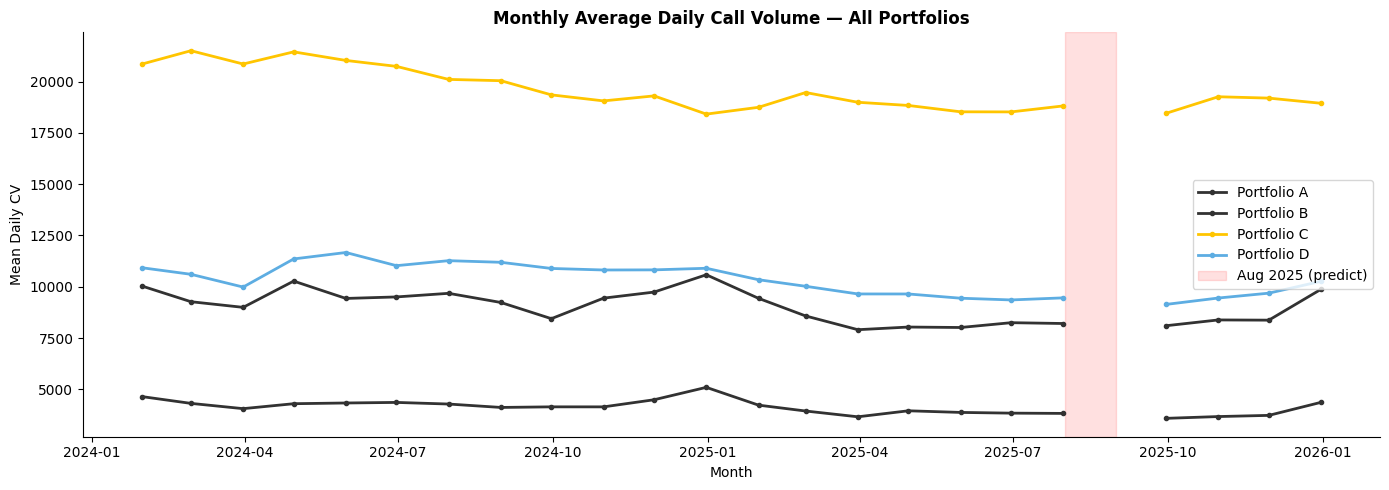

Saved slide3_monthly_trend.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

for i, p in enumerate(PORTFOLIOS):
    df = daily[p].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[~((df["Date"].dt.year == 2025) & (df["Date"].dt.month == 8))]
    monthly = df.resample("ME", on="Date")["CV"].mean()
    ax.plot(monthly.index, monthly.values, label=f"Portfolio {p}",
            color=COLORS[i], linewidth=2, marker="o", markersize=3)

ax.axvspan(pd.Timestamp("2025-08-01"), pd.Timestamp("2025-08-31"),
           alpha=0.12, color="red", label="Aug 2025 (predict)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Daily CV")
ax.set_title("Monthly Average Daily Call Volume — All Portfolios", fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide3_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slide3_monthly_trend.png")

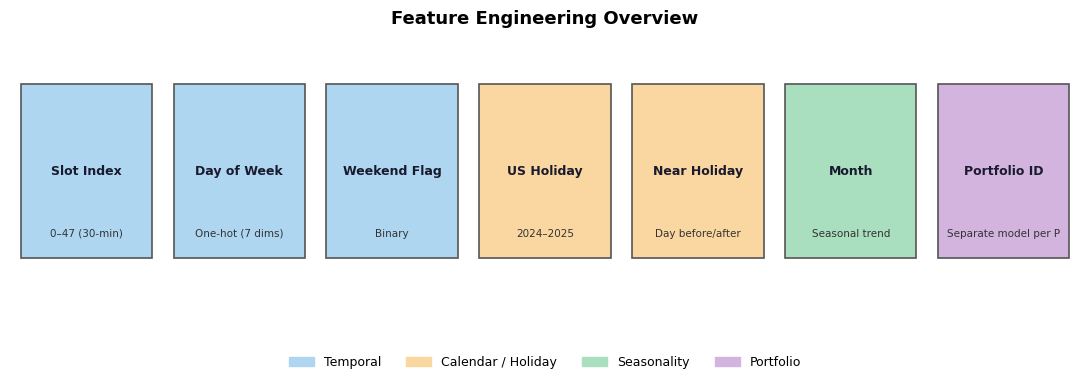

Saved slide4_features.png


In [ ]:
features = [
    ("Slot Index", "0–47 (30-min)", "#AED6F1"),
    ("Day of Week", "One-hot (7 dims)", "#AED6F1"),
    ("Weekend Flag", "Binary", "#AED6F1"),
    ("US Holiday", "2024–2025", "#FAD7A0"),
    ("Near Holiday", "Day before/after", "#FAD7A0"),
    ("Month", "Seasonal trend", "#A9DFBF"),
    ("Portfolio ID", "Separate model per P", "#D2B4DE"),
]

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

col_w = 1.0 / len(features)
for j, (name, desc, color) in enumerate(features):
    x = j * col_w + 0.01
    ax.add_patch(plt.Rectangle((x, 0.35), col_w - 0.02, 0.50,
                               transform=ax.transAxes,
                               facecolor=color, edgecolor="#555", linewidth=1.2))
    ax.text(x + (col_w - 0.02) / 2, 0.60, name,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#1A1A2E")
    ax.text(x + (col_w - 0.02) / 2, 0.42, desc,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=7.5, color="#333")

legend_items = [
    mpatches.Patch(color="#AED6F1", label="Temporal"),
    mpatches.Patch(color="#FAD7A0", label="Calendar / Holiday"),
    mpatches.Patch(color="#A9DFBF", label="Seasonality"),
    mpatches.Patch(color="#D2B4DE", label="Portfolio"),
]
ax.legend(handles=legend_items, loc="lower center", ncol=4, fontsize=9,
          bbox_to_anchor=(0.5, 0.0), frameon=False)

ax.set_title("Feature Engineering Overview", fontsize=13, fontweight="bold", pad=6)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide4_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved slide4_features.png")

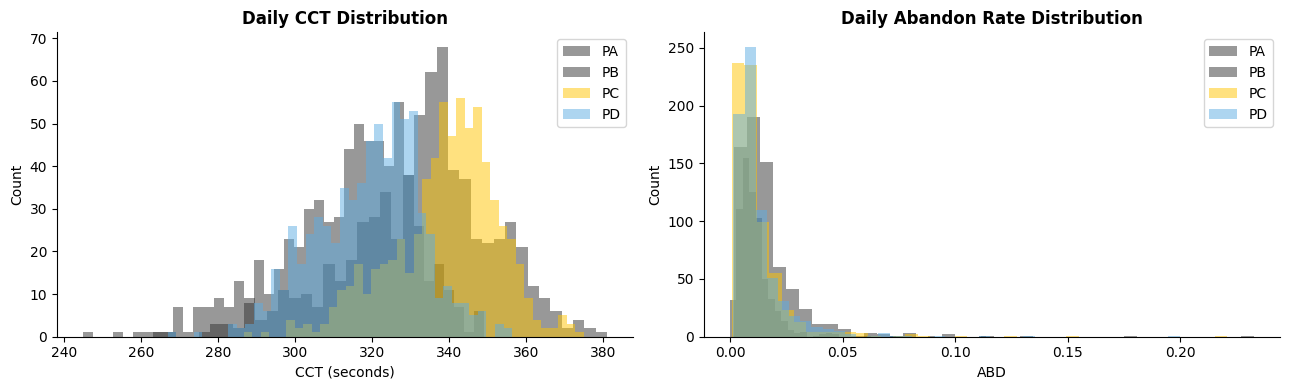

Saved slide3_cct_abd_dist.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, p in enumerate(PORTFOLIOS):
    df = daily[p].copy()
    df = df[~((pd.to_datetime(df["Date"]).dt.year == 2025) &
               (pd.to_datetime(df["Date"]).dt.month == 8))]
    axes[0].hist(df["CCT"].dropna(), bins=40, alpha=0.5, label=f"P{p}", color=COLORS[i])
    axes[1].hist(df["ABD"].dropna(), bins=40, alpha=0.5, label=f"P{p}", color=COLORS[i])

axes[0].set_title("Daily CCT Distribution", fontweight="bold")
axes[0].set_xlabel("CCT (seconds)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].set_title("Daily Abandon Rate Distribution", fontweight="bold")
axes[1].set_xlabel("ABD")
axes[1].set_ylabel("Count")
axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide3_cct_abd_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved slide3_cct_abd_dist.png")

In [9]:
rows = []
for p in PORTFOLIOS:
    df = daily[p].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[~((df["Date"].dt.year == 2025) & (df["Date"].dt.month == 8))]
    iv = interval[p]
    rows.append({
        "Portfolio": p,
        "Daily rows": len(df),
        "Mean daily CV": f"{df['CV'].mean():,.0f}",
        "Mean daily CCT": f"{df['CCT'].mean():.1f}s",
        "Mean daily ABD": f"{df['ABD'].mean():.3f}",
        "Interval rows": len(iv),
        "Missing daily days": len(pd.date_range('2024-01-01','2025-12-31',freq='D')) - df['Date'].nunique(),
    })

summary = pd.DataFrame(rows).set_index("Portfolio")
print(summary.to_string())

           Daily rows Mean daily CV Mean daily CCT Mean daily ABD  Interval rows  Missing daily days
Portfolio                                                                                           
A                 670         4,143         313.6s          0.011           3911                  61
B                 675         9,058         332.8s          0.017           4158                  56
C                 690        19,592         339.2s          0.012           4313                  41
D                 700        10,357         319.3s          0.013           4067                  31
